<a href="https://colab.research.google.com/github/leshaz44/Aliaksei/blob/main/Task_5/Task_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.443e+10, tolerance: 9.598e+07
  model = cd_fast.enet_coordinate_descent(


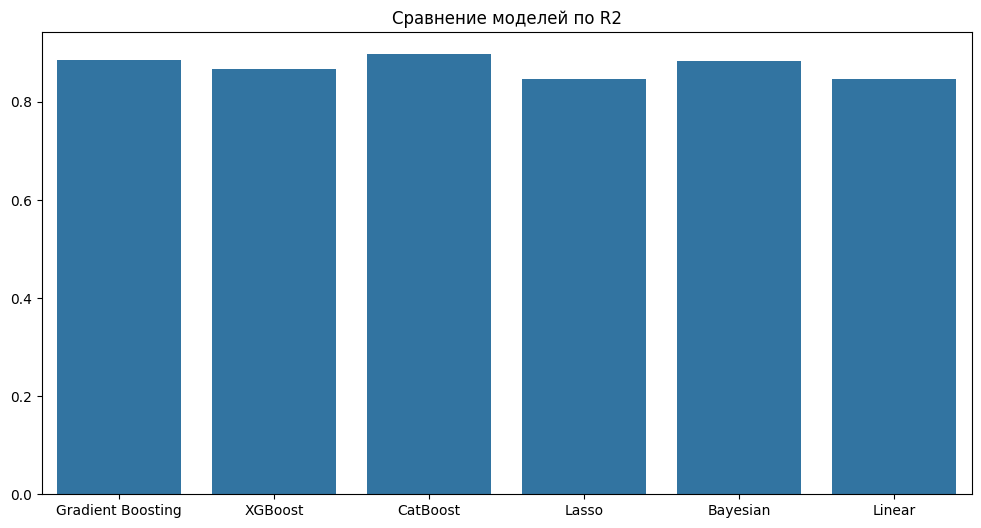

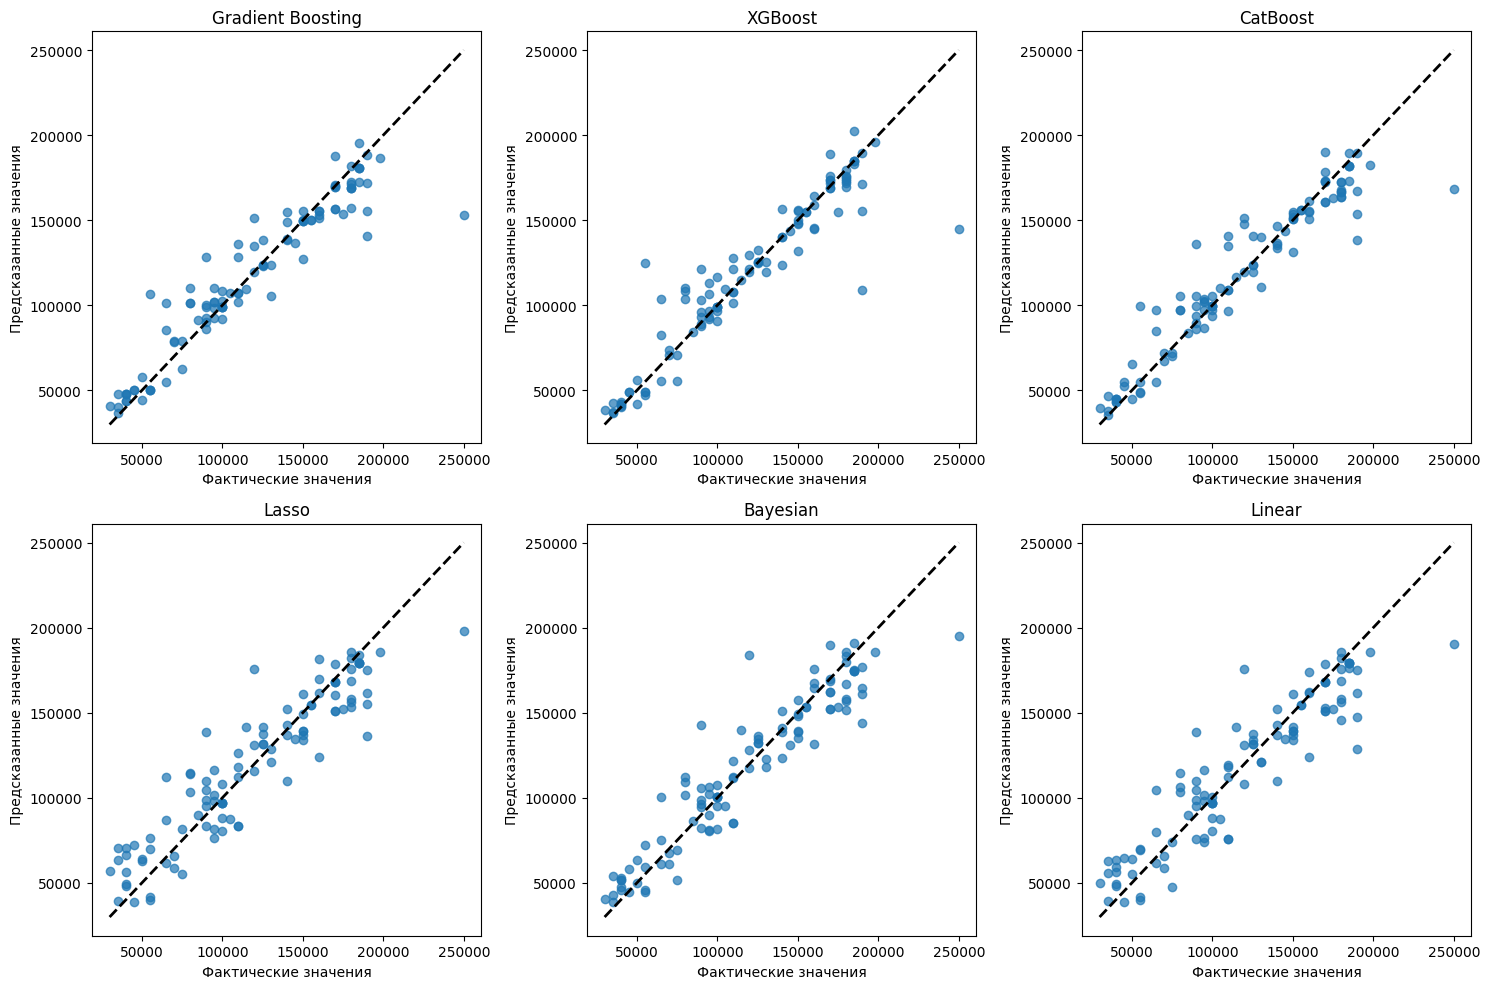

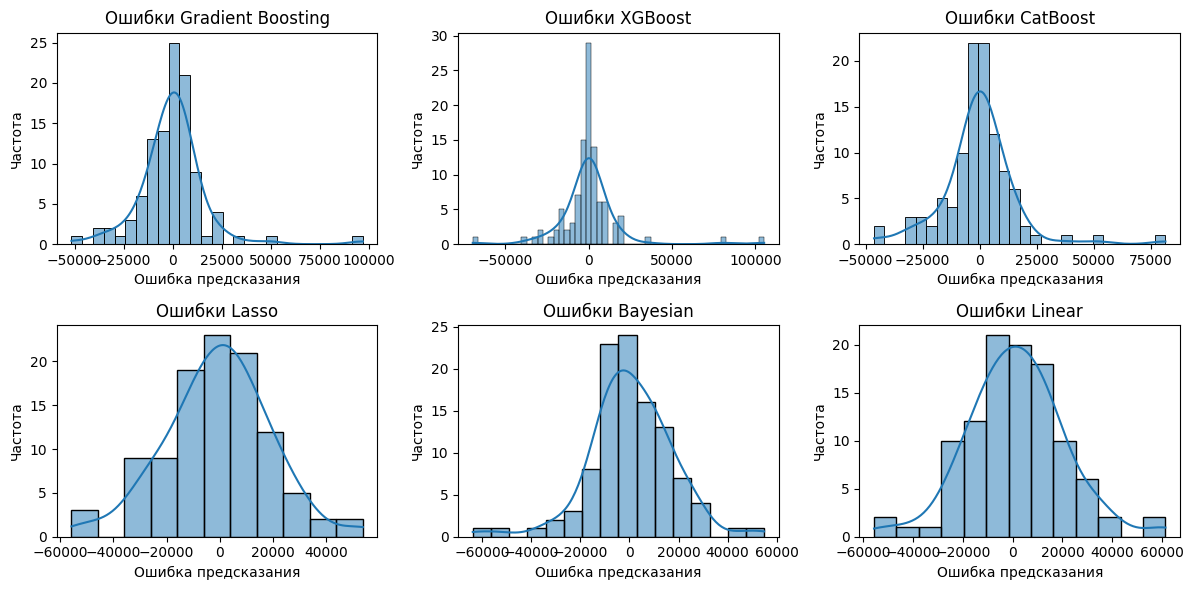

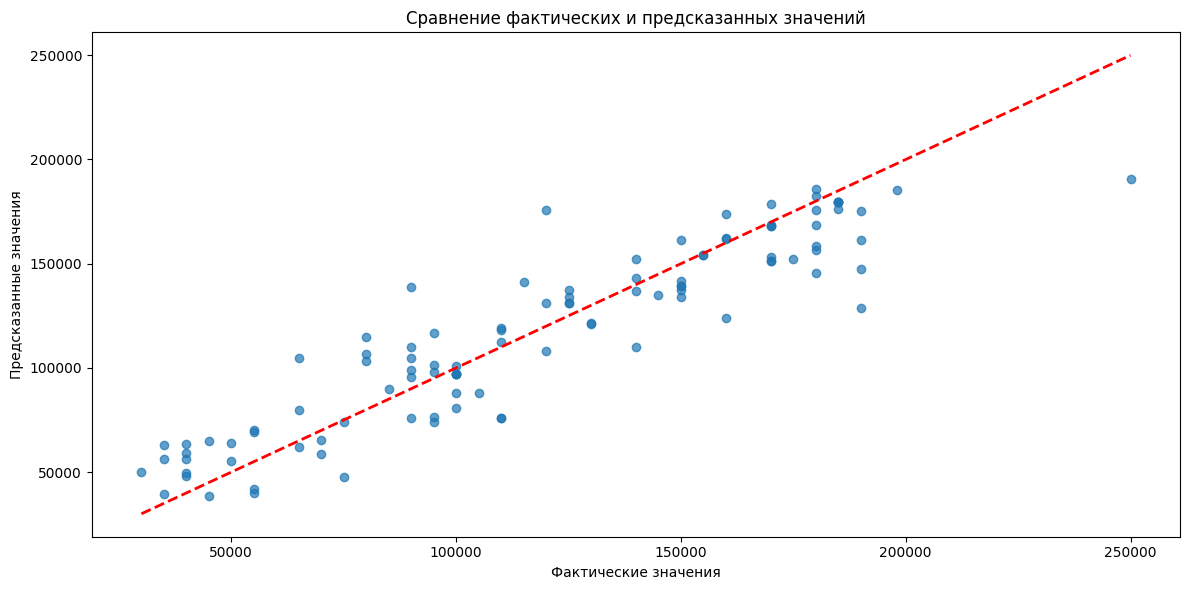


Лучшая модель: CatBoost
R2: 0.8970
MAE: 10093.77
MSE: 256932522.23


In [ ]:
#!pip install catboost
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Lasso, BayesianRidge, LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Загрузка данных
data = pd.read_csv('data_Salary2.csv')

# Определяем столбцы на основе реальных данных из датасета
categorical_cols = ['Gender', 'Education', 'Job']
numerical_cols = ['Age', 'Experience']
target_col = 'Salary'

# Проверка наличия всех необходимых столбцов
assert all(col in data.columns for col in categorical_cols + numerical_cols + [target_col]), \
    "Отсутствуют необходимые столбцы в данных"

# Предварительная обработка
def preprocess_data(X):
    # Обработка категориальных признаков
    X_cat = pd.get_dummies(X[categorical_cols], drop_first=True)
    # Обработка числовых признаков
    X_num = X[numerical_cols]
    # Объединение
    return pd.concat([X_num, X_cat], axis=1)

# Подготовка данных
X = data.drop(target_col, axis=1)
y = data[target_col]
X_processed = preprocess_data(X)

# Разделение на выборки
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Создание моделей
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42),
    'CatBoost': CatBoostRegressor(iterations=100, random_state=42, verbose=0),
    'Lasso': Lasso(alpha=0.1),
    'Bayesian': BayesianRidge(),
    'Linear': LinearRegression()
}

# Обучение и оценка
results = {}
for name, model in models.items():
    try:
        # Для CatBoost отдельно обрабатываем категориальные признаки
        if name == 'CatBoost':
            cat_features = np.where(X_processed.dtypes == 'uint8')[0]
            model.fit(X_train, y_train, cat_features=cat_features)
        else:
            model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        results[name] = {'MAE': mae, 'MSE': mse, 'R2': r2}
    except Exception as e:
        print(f"Ошибка при обучении модели {name}: {str(e)}")
        results[name] = {'MAE': np.nan, 'MSE': np.nan, 'R2': np.nan}

# Визуализация результатов
plt.figure(figsize=(12, 6))
sns.barplot(x=list(results.keys()), y=[v['R2'] for v in results.values()])
plt.title('Сравнение моделей по R2')
plt.show()

# Визуализация предсказаний для каждой модели
num_models = len(models)
cols = 3  # Количество столбцов в сетке
rows = (num_models + cols - 1) // cols  # Расчет необходимого количества строк

plt.figure(figsize=(15, 10))

for i, (name, model) in enumerate(models.items()):
    plt.subplot(rows, cols, i + 1)
    y_pred = model.predict(X_test)
    plt.scatter(y_test, y_pred, alpha=0.7)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'k--', lw=2)
    plt.title(f'{name}')
    plt.xlabel('Фактические значения')
    plt.ylabel('Предсказанные значения')
    plt.tight_layout()

# Визуализация ошибок предсказания
plt.figure(figsize=(12, 6))
for i, (name, model) in enumerate(models.items()):
    plt.subplot(2, 3, i + 1)
    y_pred = model.predict(X_test)
    errors = y_test - y_pred
    sns.histplot(errors, kde=True)
    plt.title(f'Ошибки {name}')
    plt.xlabel('Ошибка предсказания')
    plt.ylabel('Частота')
plt.tight_layout()

# Сравнение предсказаний с истинными значениями
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)
plt.title('Сравнение фактических и предсказанных значений')
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.tight_layout()
plt.show()

# Находим лучшую модель
best_model_name = max(results, key=lambda x: results[x]['R2'])
best_model = models[best_model_name]

print(f"\nЛучшая модель: {best_model_name}")
print(f"R2: {results[best_model_name]['R2']:.4f}")
print(f"MAE: {results[best_model_name]['MAE']:.2f}")
print(f"MSE: {results[best_model_name]['MSE']:.2f}")

